<a href="https://colab.research.google.com/github/kyuho11488/kyuho11488/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_6%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C_2021148025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 데이터 로딩
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Social_Network_Ads.csv')
print(df)

      User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]


In [3]:
# 데이터 전처리(preprocessing), Feature 추출

X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X)
print(y)

# 데이터 분할(80%(320개) 학습, 20%(80개))로 분할 사용하기

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

print("X_train shape : ", X_train.shape)
print("X_test shape : ", X_test.shape)
print("y_train shape : ", y_train.shape)
print("y_test shape : ", y_test.shape)

[[    19  19000]
 [    35  20000]
 [    26  43000]
 [    27  57000]
 [    19  76000]
 [    27  58000]
 [    27  84000]
 [    32 150000]
 [    25  33000]
 [    35  65000]
 [    26  80000]
 [    26  52000]
 [    20  86000]
 [    32  18000]
 [    18  82000]
 [    29  80000]
 [    47  25000]
 [    45  26000]
 [    46  28000]
 [    48  29000]
 [    45  22000]
 [    47  49000]
 [    48  41000]
 [    45  22000]
 [    46  23000]
 [    47  20000]
 [    49  28000]
 [    47  30000]
 [    29  43000]
 [    31  18000]
 [    31  74000]
 [    27 137000]
 [    21  16000]
 [    28  44000]
 [    27  90000]
 [    35  27000]
 [    33  28000]
 [    30  49000]
 [    26  72000]
 [    27  31000]
 [    27  17000]
 [    33  51000]
 [    35 108000]
 [    30  15000]
 [    28  84000]
 [    23  20000]
 [    25  79000]
 [    27  54000]
 [    30 135000]
 [    31  89000]
 [    24  32000]
 [    18  44000]
 [    29  83000]
 [    35  23000]
 [    27  58000]
 [    24  55000]
 [    23  48000]
 [    28  79000]
 [    22  1800

In [4]:
# 학습 데이터에 대해 로지스틱 회귀 모델 구성

# 시그모이드 함수 정의

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# 손실(cost) 함수 : 교차 엔트로피 손실 함수 정의

def compute_cost(X, y, w):
  m = len(y)
  z = X @ w
  h = sigmoid(z)
  epsilion = 1e-5
  cost = -(1 / m) * np.sum(y * np.log(h + epsilion) + (1 - y) * np.log(1 - h + epsilion))
  return cost

# 경사하강법 함수 정의

def gradient_descent(X, y, lr = 0.1, epochs = 10000):
  m, n = X.shape
  w = np.zeros(n)
  for epoch in range(epochs):
    z = X @ w
    h = sigmoid(z)
    gradient = (1 / m) * (X.T @ (h - y))
    w -= lr * gradient
  return w

# X_train에 절편함 추가하기

X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# 경사하강법으로 모델 학습하기

weights = gradient_descent(X_train_bias, y_train, lr = 0.1, epochs = 10000)

# 최종 파라미터 출력하기

w0, w1, w2 = weights
print("학습된 파라미터 : ")
print("w0 = ", w0)
print("w1 = ", w1)
print("w2 = ", w2)

학습된 파라미터 : 
w0 =  -1.103370800109038
w1 =  2.1771842037427014
w2 =  1.2093549152823762


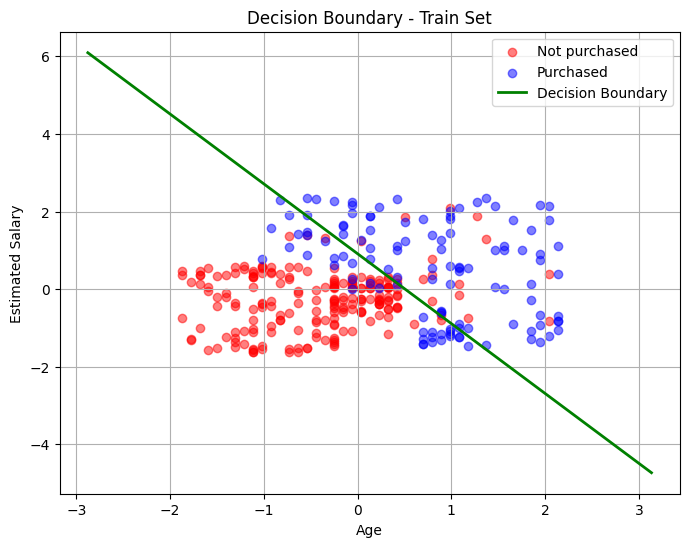

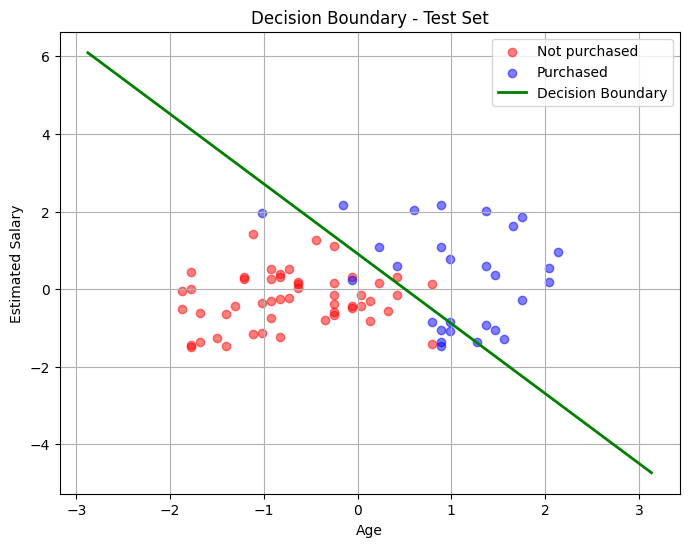

In [5]:
# 분류 경계선 시각화 함수

def plot_decision_boundary_custom(X, y, weights, title):
  x1 = X[:, 0]
  x2 = X[:, 1]

  # 경계선 계산하기

  x1_range = np.linspace(x1.min() - 1, x1.max() + 1, 100)
  x2_boundary = -(weights[0] + weights[1] * x1_range) / weights[2]

  # 산점도

  plt.figure(figsize = (8, 6))
  plt.scatter(x1[y == 0], x2[y == 0], color = 'red', label = 'Not purchased', alpha = 0.5)
  plt.scatter(x1[y == 1], x2[y == 1], color = 'blue', label = 'Purchased', alpha = 0.5)
  plt.plot(x1_range, x2_boundary, color = 'green', linewidth = 2, label = 'Decision Boundary')

  plt.title(title)
  plt.xlabel('Age')
  plt.ylabel('Estimated Salary')
  plt.legend()
  plt.grid(True)
  plt.show()

# 시각화 실행하기

# 학습 데이터 기준

plot_decision_boundary_custom(X_train, y_train, weights, "Decision Boundary - Train Set")

# 테스트 데이터 기준

plot_decision_boundary_custom(X_test, y_test, weights, "Decision Boundary - Test Set")

In [6]:
# scikit-learn library를 이용해 로지스틱 회귀 모델 학습하기

clf = LogisticRegression()
clf.fit(X_train, y_train)

# 파라미터 출력하기

w0 = clf.intercept_[0]
w1, w2 = clf.coef_[0]

print("scikit-learn 파라미터 : ")
print("w0 = ", w0)
print("w1 = ", w1)
print("w2 = ", w2)

scikit-learn 파라미터 : 
w0 =  -1.0529134008675236
w1 =  2.0125384921084057
w2 =  1.1232209304946785


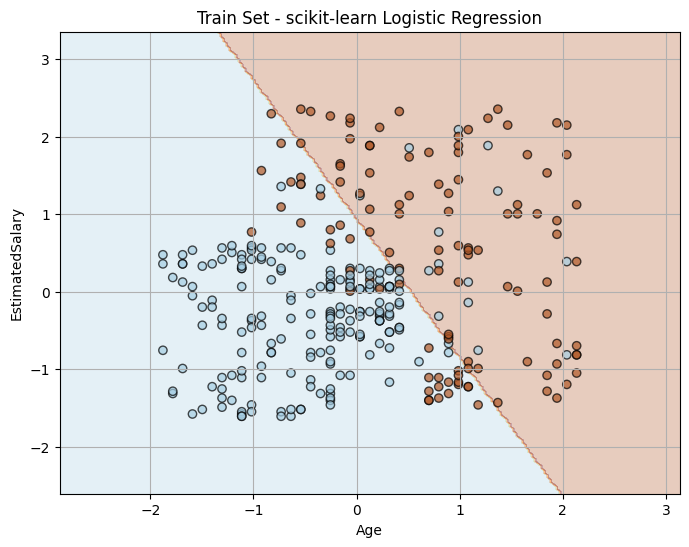

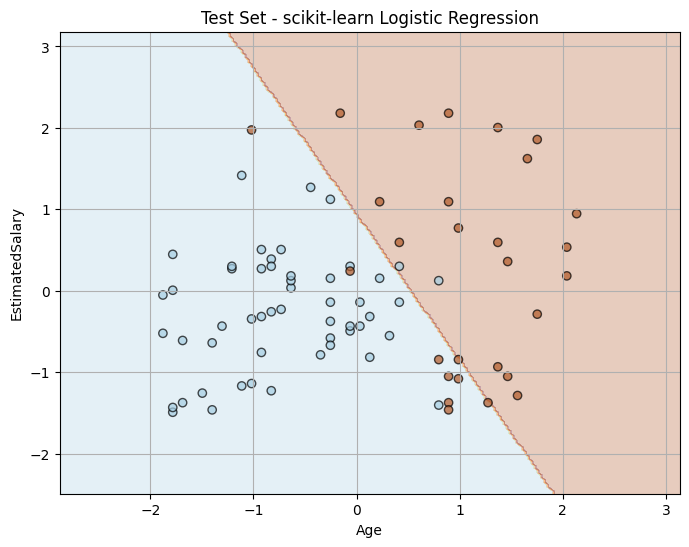

In [7]:
# 시각화 함수 정의(scikit-learn 모델 기준)

def plot_decision_boundary_sklearn(X, y, model, title):
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
  grid = np.c_[xx.ravel(), yy.ravel()]
  probs = model.predict(grid).reshape(xx.shape)

  plt.figure(figsize = (8, 6))
  plt.contourf(xx, yy, probs, alpha = 0.3, cmap = plt.cm.Paired)
  plt.scatter(X[:, 0], X[:, 1], c = y, edgecolors = 'k', cmap = plt.cm.Paired, alpha = 0.7)
  plt.title(title)
  plt.xlabel('Age')
  plt.ylabel('EstimatedSalary')
  plt.grid(True)
  plt.show()

# 시각화 실행하기

# 학습 데이터 기준 시각화

plot_decision_boundary_sklearn(X_train, y_train, clf, "Train Set - scikit-learn Logistic Regression")

# 테스트 데이터 기준 시각화

plot_decision_boundary_sklearn(X_test, y_test, clf, "Test Set - scikit-learn Logistic Regression")

In [11]:
# 평가 외 추가 코딩(로지스틱 회귀로 얻은 예측값을 테스트 데이터로 평가해보기)

# 예측

y_pred = clf.predict(X_test)

# 정확도 평가하기

accuracy = accuracy_score(y_test, y_pred)
print("테스트 데이터 정확도 : ", accuracy)

테스트 데이터 정확도 :  0.8625
